<a href="https://colab.research.google.com/github/YashTomar2201/Air-Quality-Analysis/blob/main/Assignment_1_Solution_102303766.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

In [2]:
def loadNtransform(roll_number, file_path):
    r = roll_number
    ar = 0.05 * (r % 7)
    br = 0.3 * ((r % 5) + 1)

    try:
        df = pd.read_csv(file_path, encoding='ISO-8859-1', low_memory=False)
        df['no2'] = pd.to_numeric(df['no2'], errors='coerce')
        x_raw = df['no2'].dropna()
        z_data = x_raw + ar * np.sin(br * x_raw)
        return z_data
    except Exception as e:
        print(f"Error: {e}")
        return None

roll_number = 102303766
z_data = loadNtransform(roll_number, 'data.csv')
print(f"Data loaded: {len(z_data)} samples")

Data loaded: 419509 samples


In [3]:
def gaussian(z, c, lam, mu):
    return c * np.exp(-lam * (z - mu)**2)

In [4]:
current_data = z_data.copy()
best_r2 = -np.inf
best_params = None

print("Starting refinement...")

for i in range(10):
    y_hist, x_edges = np.histogram(current_data, bins='auto', density=True)
    x_centers = (x_edges[:-1] + x_edges[1:]) / 2

    mu_guess = np.mean(current_data)
    sigma_guess = np.std(current_data)

    if sigma_guess == 0: break

    p0 = [max(y_hist), 1/(2*sigma_guess**2), mu_guess]

    try:
        popt, _ = curve_fit(gaussian, x_centers, y_hist, p0=p0,
                            bounds=([0, 0, -np.inf], [np.inf, np.inf, np.inf]),
                            maxfev=10000)
        c, lam, mu = popt

        y_pred = gaussian(x_centers, *popt)
        r2 = r2_score(y_hist, y_pred)

        sigma_derived = np.sqrt(1 / (2 * lam))

        if r2 > best_r2:
            best_r2 = r2
            best_params = popt

        print(f"Iteration {i+1}: R² = {r2:.5f}")

        lower = mu - 3 * sigma_derived
        upper = mu + 3 * sigma_derived

        prev_len = len(current_data)
        current_data = current_data[(current_data >= lower) & (current_data <= upper)]

        if len(current_data) >= prev_len * 0.99:
            print("Converged.")
            break

    except Exception as e:
        print(f"Error in loop: {e}")
        break

Starting refinement...
Iteration 1: R² = 0.70222
Iteration 2: R² = 0.36521
Converged.


In [6]:
c_final, lam_final, mu_final = best_params

print(f"FINAL PARAMETERS")
print(f"Mean (mu)    : {mu_final:.6f}")
print(f"Lambda (λ)   : {lam_final:.6f}")
print(f"Constant (c) : {c_final:.6f}")
print(f"Accuracy (R²) : {best_r2:.5f}")

FINAL PARAMETERS
Mean (mu)    : 19.748498
Lambda (λ)   : 0.003415
Constant (c) : 0.031988
Accuracy (R²) : 0.70222


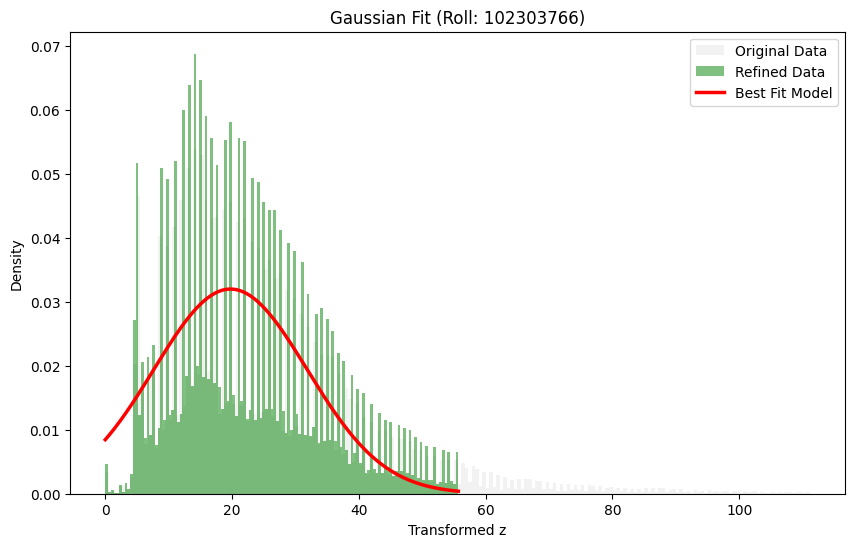

In [7]:
plt.figure(figsize=(10, 6))

limit_view = np.percentile(z_data, 99.5)
plt.hist(z_data[z_data < limit_view], bins=200, density=True, alpha=0.1, color='gray', label='Original Data')
plt.hist(current_data, bins='auto', density=True, alpha=0.5, color='green', label='Refined Data')

x_range = np.linspace(min(current_data), max(current_data), 1000)
plt.plot(x_range, gaussian(x_range, *best_params), 'r-', linewidth=2.5, label='Best Fit Model')

plt.title(f'Gaussian Fit (Roll: {roll_number})')
plt.xlabel('Transformed z')
plt.ylabel('Density')
plt.legend()
plt.show()